<a href="https://colab.research.google.com/github/CMDDclass/MS697-material/blob/main/2_MLIP_pratice_%26_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MDIL-SNU/sevennet_tutorial/blob/main/CMSS_DFT_2025/Part1_From_scratch/1_From_scratch.ipynb)

# Pratice: Utilization of universal Machine Learning Interatomic Potential (uMLIP)


## SevenNet-0 (trained by Materials project relaxation datasets)


#Installation

SevenNet can be easily installed via pip.

In [ ]:
!pip install sevenn

import os.path as osp
prefix = 'sevennet_tutorial/CMSS_DFT_2025/'

if not osp.exists(prefix):
  !git clone https://github.com/MDIL-SNU/sevennet_tutorial.git
  print("Done")

Cloning into 'sevennet_tutorial'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 195 (delta 13), reused 26 (delta 6), pack-reused 156 (from 2)
Receiving objects: 100% (195/195), 52.47 MiB | 36.65 MiB/s, done.
Resolving deltas: 100% (73/73), done.
Done


Check whether your installation is successful

In [ ]:
from sevenn.logger import Logger
logger = Logger(screen=True)
logger.greeting()

SevenNet: Scalable EquiVariance-Enabled Neural Network
version 0.11.2.post1, Sat Nov 15 01:58:22 2025

                ****
              ********                                   .
              *//////,  ..                               .            ,*.
               ,,***.         ..                        ,          ********.                                  ./,
             .      .                ..   /////.       .,       . */////////                               /////////.
        .&@&/        .                  .(((((((..     /           *//////*.  ...                         *((((((((((.
     @@@@@@@@@@*    @@@@@@@@@@  @@@@@    *((@@@@@     (     %@@@@@@@@@@  .@@@@@@     ..@@@@.   @@@@@@*    .(@@@@@(((*
    @@@@@.          @@@@         @@@@@ .   @@@@@      #     %@@@@         @@@@@@@@     @@@@(,  @@@@@@@@.    @@@@@(*.
    %@@@@@@@&       @@@@@@@@@@    @@@@@   @@@@@      #  ., .%@@@@@@@@@    @@@@@@@@@@   @@@@,   @@@@@@@@@@   @@@@@
    ,(%@@@@@@@@@    @@@@@@@@@@     @@@@@ @@

In [ ]:
# Cell 1: Import libraries and setup
"""
SevenNet Pretrained Model Tutorial
====================================
This tutorial demonstrates:
1. Using SevenNet pretrained models
2. Comparing MLIP predictions with DFT reference data
3. Calculating energy softening scale through linear regression
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy import stats
from ase.io import read
from ase.units import bar
import torch
import gc
from tqdm import tqdm
import os.path as osp

from sevenn.calculator import SevenNetCalculator
from sevenn.util import pretrained_name_to_path

print("Setup complete!")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")

Setup complete!
PyTorch CUDA available: True


In [ ]:
# Cell 2: Check available pretrained models
"""
SevenNet Pretrained Models
--------------------------
SevenNet provides several pretrained models trained on different datasets.
Let's see what's available:
"""

available_models = ['7net-0', '7net-l3i5', '7net-mf-ompa', '7net-omat']

print("Available SevenNet Pretrained Models:")
print("=" * 60)
for model_name in available_models:
    try:
        model_path = pretrained_name_to_path(model_name)
        print(f"✓ {model_name}")
        print(f"  Path: {model_path}")
    except:
        print(f"✗ {model_name} (not found)")
print("=" * 60)

# We will use 7net-0 for this tutorial
# You can change here-----------------------------------------------------------------------
selected_model =
# ------------------------------------------------------------------------------------------

print(f"\n📌 Selected model for this tutorial: {selected_model}")
print("This is the baseline SevenNet model trained on diverse materials.")

Available SevenNet Pretrained Models:
✓ 7net-0
  Path: /usr/local/lib/python3.12/dist-packages/sevenn/pretrained_potentials/SevenNet_0__11Jul2024/checkpoint_sevennet_0.pth
✓ 7net-l3i5
  Path: /usr/local/lib/python3.12/dist-packages/sevenn/pretrained_potentials/SevenNet_l3i5/checkpoint_l3i5.pth


Checkpoint downloaded: /usr/local/lib/python3.12/dist-packages/sevenn/pretrained_potentials/SevenNet_MF_ompa/checkpoint_sevennet_mf_ompa.pth
✓ 7net-mf-ompa
  Path: /usr/local/lib/python3.12/dist-packages/sevenn/pretrained_potentials/SevenNet_MF_ompa/checkpoint_sevennet_mf_ompa.pth


Checkpoint downloaded: /usr/local/lib/python3.12/dist-packages/sevenn/pretrained_potentials/SevenNet_omat/checkpoint_sevennet_omat.pth
✓ 7net-omat
  Path: /usr/local/lib/python3.12/dist-packages/sevenn/pretrained_potentials/SevenNet_omat/checkpoint_sevennet_omat.pth

📌 Selected model for this tutorial: 7net-0
This is the baseline SevenNet model trained on diverse materials.


In [ ]:
# Cell 3: Load and sample trajectory data
"""
Load 600K Trajectory Data
-------------------------
We'll load the trajectory file and randomly sample 10% of the structures
to make calculations faster while maintaining statistical significance.
"""

prefix = 'sevennet_tutorial/CMSS_DFT_2025/'
traj_file = f'{prefix}/data/600K.extxyz'

# Load all structures
print(f"Loading trajectory from: {traj_file}")
full_traj = read(traj_file, ':')
print(f"Total number of structures: {len(full_traj)}")

# Random sampling (10%)
np.random.seed(42)  # For reproducibility
sample_ratio = 0.10
num_samples = int(len(full_traj) * sample_ratio)
sample_indices = np.random.choice(len(full_traj), num_samples, replace=False)
sample_indices = np.sort(sample_indices)  # Sort for easier tracking

traj = [full_traj[i] for i in sample_indices]
print(f"\n✓ Sampled {len(traj)} structures ({sample_ratio*100:.0f}% of total)")
print(f"Sample indices: {sample_indices[:10]}... (showing first 10)")

Loading trajectory from: sevennet_tutorial/CMSS_DFT_2025//data/600K.extxyz
Total number of structures: 85

✓ Sampled 8 structures (10% of total)
Sample indices: [ 0 10 12 18 22 68 78 82]... (showing first 10)


In [ ]:
# Cell 4: Extract DFT reference data
"""
Extract DFT Reference Data
--------------------------
Extract energy, forces, and stress from DFT calculations stored in the trajectory.
These will serve as ground truth for comparison.
"""

dft_energy = []      # Energy per atom (eV/atom)
dft_forces = []      # Forces (eV/Å)
dft_stress = []      # Stress (kbar)
to_kBar = 1/bar/1000

print("Extracting DFT reference data...")
for atoms in tqdm(traj, desc='Processing DFT labels'):
    # Energy per atom
    dft_energy.append(atoms.get_potential_energy() / len(atoms))

    # Forces (flatten to 1D array)
    dft_forces.extend(atoms.get_forces().flatten())

    # Stress (convert to kbar)
    dft_stress.extend(atoms.get_stress().flatten() * to_kBar)

print(f"\n✓ Extracted DFT data:")
print(f"  - Energies: {len(dft_energy)} values")
print(f"  - Forces: {len(dft_forces)} components")
print(f"  - Stress: {len(dft_stress)} components")
print(f"\nEnergy statistics (eV/atom):")
print(f"  Mean: {np.mean(dft_energy):.4f}")
print(f"  Std:  {np.std(dft_energy):.4f}")
print(f"  Min:  {np.min(dft_energy):.4f}")
print(f"  Max:  {np.max(dft_energy):.4f}")

Extracting DFT reference data...


Processing DFT labels: 100%|██████████| 8/8 [00:00<00:00, 604.85it/s]


✓ Extracted DFT data:
  - Energies: 8 values
  - Forces: 9984 components
  - Stress: 48 components

Energy statistics (eV/atom):
  Mean: -6.5328
  Std:  0.0093
  Min:  -6.5418
  Max:  -6.5103


In [ ]:
# Cell 5: Run MLIP inference with pretrained model (FIXED)
"""
MLIP Inference with SevenNet Pretrained Model
----------------------------------------------
Use the selected pretrained model (7net-0) to predict energies, forces,
and stresses for all sampled structures.
"""

mlip_energy = []
mlip_forces = []
mlip_stress = []

print(f"Loading SevenNet calculator with model: {selected_model}")
calc = SevenNetCalculator(selected_model)
print(f"✓ Calculator loaded successfully")
print(f"  Cutoff radius: {calc.cutoff} Å")
print(f"  Device: {calc.device}")

print(f"\nRunning MLIP inference on {len(traj)} structures...")
for atoms in tqdm(traj, desc=f'{selected_model} prediction'):
    # Attach calculator to atoms object
    atoms.calc = calc

# You can change here-----------------------------------------------------------------------


# ------------------------------------------------------------------------------------------

    # Clean up calculator reference
    atoms.calc = None

# Free up memory
del calc
gc.collect()
torch.cuda.empty_cache()

print(f"\n✓ MLIP predictions complete!")
print(f"  - Energies: {len(mlip_energy)} values")
print(f"  - Forces: {len(mlip_forces)} components")
print(f"  - Stress: {len(mlip_stress)} components")

# Verify data consistency
print(f"\n🔍 Data consistency check:")
print(f"  DFT energies:  {len(dft_energy)} structures")
print(f"  MLIP energies: {len(mlip_energy)} structures")
print(f"  DFT forces:    {len(dft_forces)} components")
print(f"  MLIP forces:   {len(mlip_forces)} components")
print(f"  DFT stress:    {len(dft_stress)} components")
print(f"  MLIP stress:   {len(mlip_stress)} components")

if len(dft_forces) != len(mlip_forces):
    print(f"  ⚠️  WARNING: Force component mismatch!")
else:
    print(f"  ✓ All data arrays have consistent sizes")

Loading SevenNet calculator with model: 7net-0
✓ Calculator loaded successfully
  Cutoff radius: 5.0 Å
  Device: cuda

Running MLIP inference on 8 structures...


7net-0 prediction: 100%|██████████| 8/8 [00:01<00:00,  5.22it/s]



✓ MLIP predictions complete!
  - Energies: 8 values
  - Forces: 9984 components
  - Stress: 48 components

🔍 Data consistency check:
  DFT energies:  8 structures
  MLIP energies: 8 structures
  DFT forces:    9984 components
  MLIP forces:   9984 components
  DFT stress:    48 components
  MLIP stress:   48 components
  ✓ All data arrays have consistent sizes


In [ ]:
# Cell 6: Calculate prediction errors
"""
Calculate Prediction Errors
----------------------------
Compute RMSE and MAE for energy, force, and stress predictions.
"""

def calculate_errors(y_true, y_pred, name):
    """Calculate RMSE and MAE"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

# You can change here-----------------------------------------------------------------------
    errors =
    rmse =
    mae =

    return rmse, mae
# ------------------------------------------------------------------------------------------

# Calculate errors
energy_rmse, energy_mae = calculate_errors(dft_energy, mlip_energy, 'Energy')
force_rmse, force_mae = calculate_errors(dft_forces, mlip_forces, 'Force')
stress_rmse, stress_mae = calculate_errors(dft_stress, mlip_stress, 'Stress')

print("=" * 70)
print(f"MLIP Prediction Errors ({selected_model})")
print("=" * 70)
print(f"{'Property':<15} {'RMSE':<20} {'MAE':<20}")
print("-" * 70)
print(f"{'Energy':<15} {energy_rmse:>10.4f} eV/atom   {energy_mae:>10.4f} eV/atom")
print(f"{'Force':<15} {force_rmse:>10.4f} eV/Å       {force_mae:>10.4f} eV/Å")
print(f"{'Stress':<15} {stress_rmse:>10.4f} kbar       {stress_mae:>10.4f} kbar")
print("=" * 70)

MLIP Prediction Errors (7net-0)
Property        RMSE                 MAE                 
----------------------------------------------------------------------
Energy              2.4356 eV/atom       2.4356 eV/atom
Force               0.1559 eV/Å           0.1152 eV/Å
Stress              5.9992 kbar           4.4233 kbar


In [ ]:
# Cell 6.5: Prepare relative energies for better visualization
"""
Prepare Relative Energies
--------------------------
Since absolute energies have very narrow ranges, we'll convert to relative energies
by subtracting the mean. This highlights the energy variations more clearly.
"""

# Calculate mean energies
dft_energy_mean = np.mean(dft_energy)
mlip_energy_mean = np.mean(mlip_energy)

# Convert to relative energies (deviation from mean)
dft_energy_rel = np.array(dft_energy) - dft_energy_mean
mlip_energy_rel = np.array(mlip_energy) - mlip_energy_mean

print("=" * 70)
print("Energy Statistics Comparison")
print("=" * 70)
print(f"\nAbsolute Energies (eV/atom):")
print(f"  DFT  - Mean: {dft_energy_mean:.4f}, Std: {np.std(dft_energy):.4f}")
print(f"  MLIP - Mean: {mlip_energy_mean:.4f}, Std: {np.std(mlip_energy):.4f}")
print(f"  Range: {np.max(dft_energy) - np.min(dft_energy):.4f} eV/atom")

print(f"\nRelative Energies (eV/atom, mean-centered):")
print(f"  DFT  - Mean: {np.mean(dft_energy_rel):.4f}, Std: {np.std(dft_energy_rel):.4f}")
print(f"  MLIP - Mean: {np.mean(mlip_energy_rel):.4f}, Std: {np.std(mlip_energy_rel):.4f}")
print(f"  Range: {np.max(dft_energy_rel) - np.min(dft_energy_rel):.4f} eV/atom")

print(f"\n✓ Relative energies prepared for visualization")
print(f"  This transformation makes energy variations more visible in plots.")
print("=" * 70)

Energy Statistics Comparison

Absolute Energies (eV/atom):
  DFT  - Mean: -6.5353, Std: 0.0055
  MLIP - Mean: -4.0996, Std: 0.0043
  Range: 0.0328 eV/atom

Relative Energies (eV/atom, mean-centered):
  DFT  - Mean: -0.0000, Std: 0.0055
  MLIP - Mean: 0.0000, Std: 0.0043
  Range: 0.0328 eV/atom

✓ Relative energies prepared for visualization
  This transformation makes energy variations more visible in plots.


Generating parity plots with relative energies...


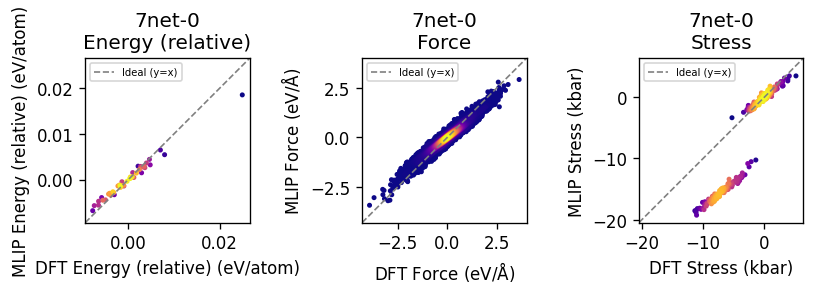

✓ Parity plots generated (energy shown as relative to mean)


In [ ]:
# Cell 7: Density-colored parity plots (UPDATED)
"""
Parity Plots: DFT vs MLIP
--------------------------
Visualize the agreement between DFT reference and MLIP predictions.
For energy, we use RELATIVE energies (mean-centered) to better show variations.
Density coloring helps identify regions with more data points.
"""

def density_colored_scatter_plot(
    dft_energy,
    mlip_energy,
    dft_force,
    mlip_force,
    dft_stress,
    mlip_stress,
    title=None,
    use_relative_energy=True
):
    """
    Create density-colored scatter plots for energy, force, and stress.
    Higher density regions appear brighter in the colormap.
    """
    modes = ['Energy (relative)', 'Force', 'Stress']
    units = {"Energy (relative)": "eV/atom", "Force": r"eV/$\rm{\AA}$", "Stress": "kbar"}

    plt.figure(figsize=(18/2.54, 6/2.54), dpi=120)

    data_pairs = [
        (dft_energy, mlip_energy),
        (dft_force, mlip_force),
        (dft_stress, mlip_stress)
    ]

    for num, (x, y) in enumerate(data_pairs):
        mode = modes[num]

        # Subsample if too many points (for KDE calculation)
        idx = (
            np.random.choice(len(x), 1000, replace=False)
            if len(x) > 1000
            else list(range(len(x)))
        )
        xsam = [x[i] for i in idx]
        ysam = [y[i] for i in idx]

        # Calculate kernel density estimation for coloring
        xy = np.vstack([x, y])
        xysam = np.vstack([xsam, ysam])
        zsam = gaussian_kde(xysam)
        z = zsam.pdf(xy)

        # Sort by density for better visualization
        idx = z.argsort()
        x_sorted = [x[i] for i in idx]
        y_sorted = [y[i] for i in idx]
        z_sorted = [z[i] for i in idx]

        # Create subplot
        ax = plt.subplot(1, 3, num+1)
        plt.scatter(x_sorted, y_sorted, c=z_sorted, s=4, cmap='plasma')

        # Add ideal parity line (y=x)
        mini = min(min(x), min(y))
        maxi = max(max(x), max(y))
        ran = (maxi - mini) / 20
        plt.plot(
            [mini-ran, maxi+ran],
            [mini-ran, maxi+ran],
            color='grey',
            linestyle='dashed',
            linewidth=1,
            label='Ideal (y=x)'
        )

        plt.xlim(mini-ran, maxi+ran)
        plt.ylim(mini-ran, maxi+ran)
        plt.xlabel(f'DFT {mode} ({units[mode]})')
        plt.ylabel(f'MLIP {mode} ({units[mode]})')
        ax.set_aspect('equal')

        if title:
            ax.set_title(f'{title}\n{mode}')
        else:
            ax.set_title(mode)

        plt.legend(loc='upper left', fontsize=6)

    plt.tight_layout()
    plt.show()

# Generate parity plots using RELATIVE energies
print("Generating parity plots with relative energies...")
density_colored_scatter_plot(
    dft_energy_rel,      # Use relative energy
    mlip_energy_rel,     # Use relative energy
    dft_forces,
    mlip_forces,
    dft_stress,
    mlip_stress,
    title=selected_model,
)
print("✓ Parity plots generated (energy shown as relative to mean)")

# Homework

In [ ]:
# Cell 8: Linear regression analysis for energy and force
"""
Linear Regression Analysis
---------------------------
Perform linear regression on relative energies and forces to quantify
prediction accuracy and energy softening scale.
"""

# === Energy Linear Regression (Relative) ===
dft_energy_rel_array = np.array(dft_energy_rel)
mlip_energy_rel_array = np.array(mlip_energy_rel)

slope, intercept, r_value, p_value, std_err = stats.linregress(
# You can change here-----------------------------------------------------------------------


# ------------------------------------------------------------------------------------------

)
r_squared = r_value ** 2

# === Force Linear Regression ===
# Convert lists to numpy arrays and flatten
dft_forces_array = np.array(dft_forces).flatten()
mlip_forces_array = np.array(mlip_forces).flatten()

print(f"Preparing force data for regression...")
print(f"  DFT forces shape: {dft_forces_array.shape}")
print(f"  MLIP forces shape: {mlip_forces_array.shape}")

slope_force, intercept_force, r_value_force, p_value_force, std_err_force = stats.linregress(
# You can change here-----------------------------------------------------------------------


# ------------------------------------------------------------------------------------------
)
r_squared_force = r_value_force ** 2

# === Print Results ===
print("\n" + "=" * 70)
print("Linear Regression Analysis Results")
print("=" * 70)

print(f"\n📊 RELATIVE ENERGY Analysis:")
print(f"   Model: E_MLIP_rel = slope × E_DFT_rel + intercept")
print(f"   -" * 35)
print(f"   Slope (Energy Softening Scale): {slope:.6f} ± {std_err:.6f}")
print(f"   Intercept:                      {intercept:.6f} eV/atom")
print(f"   R² (determination coefficient): {r_squared:.6f}")
print(f"   Pearson correlation:            {r_value:.6f}")
print(f"   p-value:                        {p_value:.2e}")

print(f"\n📊 FORCE Analysis:")
print(f"   Model: F_MLIP = slope × F_DFT + intercept")
print(f"   -" * 35)
print(f"   Slope:                          {slope_force:.6f} ± {std_err_force:.6f}")
print(f"   Intercept:                      {intercept_force:.6f} eV/Å")
print(f"   R² (determination coefficient): {r_squared_force:.6f}")
print(f"   Pearson correlation:            {r_value_force:.6f}")
print(f"   RMSE:                           {force_rmse:.6f} eV/Å")
print(f"   MAE:                            {force_mae:.6f} eV/Å")

print(f"\n💡 Energy Softening Interpretation:")
if slope > 1.01:
    print(f"   ⚠️  MLIP overestimates energy variations by {(slope-1)*100:.2f}%")
    print(f"   → Energy fluctuations are exaggerated in MLIP predictions")
elif slope < 0.99:
    softening = (1 - slope) * 100
    print(f"   ⚠️  MLIP underestimates (softens) energy variations by {softening:.2f}%")
    print(f"   → Energy landscape appears 'flatter' in MLIP predictions")
else:
    print(f"   ✓ MLIP shows excellent agreement with DFT (slope ≈ 1)")
    print(f"   → Energy variations are accurately captured")

print(f"\n💡 Force Prediction Interpretation:")
if slope_force > 1.01:
    print(f"   ⚠️  MLIP overestimates forces by {(slope_force-1)*100:.2f}%")
elif slope_force < 0.99:
    print(f"   ⚠️  MLIP underestimates forces by {(1-slope_force)*100:.2f}%")
else:
    print(f"   ✓ MLIP shows excellent force prediction (slope ≈ 1)")

print(f"\n📌 Physical Significance:")
print(f"   Energy softening affects:")
print(f"   - MD trajectory accuracy (dynamics)")
print(f"   - Free energy barriers (reaction rates)")
print(f"   - Phase stability predictions")
print(f"\n   Force accuracy affects:")
print(f"   - Atomic trajectories in MD")
print(f"   - Structure optimization convergence")
print(f"   - Vibrational properties")

print("=" * 70)

Preparing force data for regression...
  DFT forces shape: (9984,)
  MLIP forces shape: (9984,)

Linear Regression Analysis Results

📊 RELATIVE ENERGY Analysis:
   Model: E_MLIP_rel = slope × E_DFT_rel + intercept
   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -
   Slope (Energy Softening Scale): 0.776559 ± 0.015521
   Intercept:                      0.000000 eV/atom
   R² (determination coefficient): 0.984271
   Pearson correlation:            0.992105
   p-value:                        1.08e-37

📊 FORCE Analysis:
   Model: F_MLIP = slope × F_DFT + intercept
   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -
   Slope:                          0.793466 ± 0.002086
   Intercept:                      0.000008 eV/Å
   R² (determination coefficient): 0.935463
   Pearson correlation:            0.967193
   RMSE: 

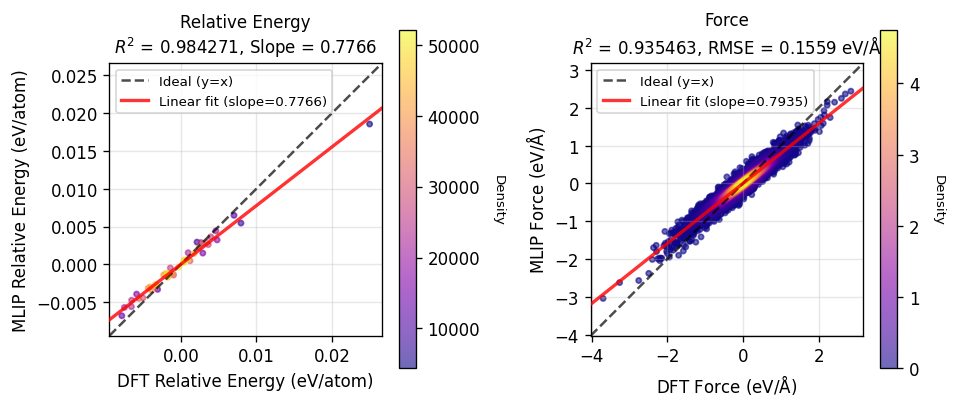


✓ Parity plots generated successfully!

Left plot - Relative Energy:
  • Energy softening scale (slope): 0.776559
  • Shows how well MLIP captures energy variations
  • Deviation from slope=1 indicates systematic bias

Right plot - Force:
  • Force prediction slope: 0.793466
  • RMSE: 0.155922 eV/Å
  • Critical for accurate MD trajectories


In [ ]:
# Cell 9: Parity plots with linear fit - Energy and Force
"""
Parity Plots with Linear Regression
------------------------------------
Visualize DFT vs MLIP predictions with density coloring and linear fit.
Left: Relative energy (highlights energy softening scale)
Right: Force (critical for MD simulations)
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20/2.54, 9/2.54), dpi=120)

# ========================================================================
# LEFT PLOT: Relative Energy with Linear Fit
# ========================================================================

# Calculate density for coloring
xy = np.vstack([dft_energy_rel_array, mlip_energy_rel_array])
if len(dft_energy_rel_array) > 1000:
    idx_sample = np.random.choice(len(dft_energy_rel_array), 1000, replace=False)
    xy_sample = np.vstack([dft_energy_rel_array[idx_sample], mlip_energy_rel_array[idx_sample]])
    kde = gaussian_kde(xy_sample)
else:
    kde = gaussian_kde(xy)

density = kde.pdf(xy)

# Sort by density for better visualization
idx = density.argsort()
dft_sorted = dft_energy_rel_array[idx]
mlip_sorted = mlip_energy_rel_array[idx]
density_sorted = density[idx]

# Scatter plot with density coloring
scatter1 = ax1.scatter(
    dft_sorted,
    mlip_sorted,
    c=density_sorted,
    s=10,
    cmap='plasma',
    alpha=0.6
)

# Set axis limits
mini = min(dft_energy_rel_array.min(), mlip_energy_rel_array.min())
maxi = max(dft_energy_rel_array.max(), mlip_energy_rel_array.max())
margin = (maxi - mini) * 0.05

# Ideal parity line (y=x)
ax1.plot(
    [mini-margin, maxi+margin],
    [mini-margin, maxi+margin],
    'k--',
    linewidth=1.5,
    label='Ideal (y=x)',
    alpha=0.7,
    zorder=3
)

# Linear regression fit line
x_fit = np.array([mini-margin, maxi+margin])
y_fit = slope * x_fit + intercept
ax1.plot(
    x_fit,
    y_fit,
    'r-',
    linewidth=2,
    label=f'Linear fit (slope={slope:.4f})',
    alpha=0.8,
    zorder=3
)

ax1.set_xlim(mini-margin, maxi+margin)
ax1.set_ylim(mini-margin, maxi+margin)
ax1.set_xlabel('DFT Relative Energy (eV/atom)', fontsize=10)
ax1.set_ylabel('MLIP Relative Energy (eV/atom)', fontsize=10)
ax1.set_aspect('equal')
ax1.set_title(f'Relative Energy\n$R^2$ = {r_squared:.6f}, Slope = {slope:.4f}', fontsize=10)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Density', rotation=270, labelpad=15, fontsize=8)

# ========================================================================
# RIGHT PLOT: Force with Linear Fit
# ========================================================================

# Calculate density for force coloring
xy_force = np.vstack([dft_forces_array, mlip_forces_array])
if len(dft_forces_array) > 1000:
    idx_force_sample = np.random.choice(len(dft_forces_array), 1000, replace=False)
    xy_force_sample = np.vstack([dft_forces_array[idx_force_sample], mlip_forces_array[idx_force_sample]])
    kde_force = gaussian_kde(xy_force_sample)
else:
    kde_force = gaussian_kde(xy_force)

density_force = kde_force.pdf(xy_force)

# Sort by density
idx_force = density_force.argsort()
dft_force_sorted = dft_forces_array[idx_force]
mlip_force_sorted = mlip_forces_array[idx_force]
density_force_sorted = density_force[idx_force]

# Scatter plot with density coloring
scatter2 = ax2.scatter(
    dft_force_sorted,
    mlip_force_sorted,
    c=density_force_sorted,
    s=10,
    cmap='plasma',
    alpha=0.6
)

# Set axis limits
mini_force = min(dft_forces_array.min(), mlip_forces_array.min())
maxi_force = max(dft_forces_array.max(), mlip_forces_array.max())
margin_force = (maxi_force - mini_force) * 0.05

# Ideal parity line (y=x)
ax2.plot(
    [mini_force-margin_force, maxi_force+margin_force],
    [mini_force-margin_force, maxi_force+margin_force],
    'k--',
    linewidth=1.5,
    label='Ideal (y=x)',
    alpha=0.7,
    zorder=3
)

# Linear regression fit line
x_fit_force = np.array([mini_force-margin_force, maxi_force+margin_force])
y_fit_force = slope_force * x_fit_force + intercept_force
ax2.plot(
    x_fit_force,
    y_fit_force,
    'r-',
    linewidth=2,
    label=f'Linear fit (slope={slope_force:.4f})',
    alpha=0.8,
    zorder=3
)

ax2.set_xlim(mini_force-margin_force, maxi_force+margin_force)
ax2.set_ylim(mini_force-margin_force, maxi_force+margin_force)
ax2.set_xlabel(r'DFT Force (eV/$\rm{\AA}$)', fontsize=10)
ax2.set_ylabel(r'MLIP Force (eV/$\rm{\AA}$)', fontsize=10)
ax2.set_aspect('equal')
ax2.set_title(f'Force\n$R^2$ = {r_squared_force:.6f}, RMSE = {force_rmse:.4f} eV/Å', fontsize=10)
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Density', rotation=270, labelpad=15, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n✓ Parity plots generated successfully!")
print(f"\nLeft plot - Relative Energy:")
print(f"  • Energy softening scale (slope): {slope:.6f}")
print(f"  • Shows how well MLIP captures energy variations")
print(f"  • Deviation from slope=1 indicates systematic bias")
print(f"\nRight plot - Force:")
print(f"  • Force prediction slope: {slope_force:.6f}")
print(f"  • RMSE: {force_rmse:.6f} eV/Å")
print(f"  • Critical for accurate MD trajectories")